In [1]:
import os
import math
import time
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pwlf
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from bika import BiKA_Linear, BiKA_Conv2d

# GPU Setting

#### After decided which GPU to train, don't change it before completing the training

In [2]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [3]:
GPU_device = "cuda:0"

# Training date output folder path

#### For different network model setting, please change the name of save_path

In [4]:
save_path     = "LFC_BiKA"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/new KAN/BiKA/experiment/MLP-like/MNIST/dataset 

Training Data Output Path:  /home/yuhao/project/new KAN/BiKA/experiment/MLP-like/MNIST/train/LFC_BiKA 

Training Report Output Path:  /home/yuhao/project/new KAN/BiKA/experiment/MLP-like/MNIST/report


# Hyperparameter Setups

In [5]:
epochs = 200
batch_sizes = [256, 512, 1024]
dropout_rates = [0.0]
lr_max_pool = [0.0010, 0.0005, 0.0002, 0.0001]
lr_min_pool = [0.000001]

# Network Definition

In [6]:
input_length = 28*28
hidden_0 = 1024
hidden_1 = 1024
hidden_2 = 1024
output_length = 10

In [7]:
class MLP(nn.Module):
    def __init__(self, dropout=0.5):
        super(MLP, self).__init__()
        
        self.fc0   = BiKA_Linear(in_features=input_length, out_features=hidden_0)
        self.drop0 = nn.Dropout(dropout)
        
        self.fc1   = BiKA_Linear(in_features=hidden_0, out_features=hidden_1)
        self.drop1 = nn.Dropout(dropout)
        
        self.fc2   = BiKA_Linear(in_features=hidden_1, out_features=hidden_2)
        self.drop2 = nn.Dropout(dropout)
        
        self.out   = BiKA_Linear(in_features=hidden_2, out_features=output_length)

    def forward(self, x):
        
        out = x.reshape(x.shape[0], -1)
        
        out = self.drop0(self.fc0(out))
        out = self.drop1(self.fc1(out))
        out = self.drop2(self.fc2(out))
        out = self.out(out)
        
        return out

# Random Seed Utility

In [8]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [9]:
test_batch_size = 4096

In [10]:
def get_dataloaders(batch_size):    
    train_dataset = datasets.MNIST(  dataset_root, 
                                     train=True, 
                                     download=True,
                                     transform=transforms.Compose
                                     ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                     ])
                                  )
    test_dataset  = datasets.MNIST( dataset_root, 
                                    train=False, 
                                    download=True,
                                    transform=transforms.Compose
                                    ([
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.5,), (0.5,))
                                    ])
                                  )
    val_size = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_set, val_set = random_split(train_dataset, [train_size, val_size])
    return (
        DataLoader(
            train_set,
            batch_size=batch_size,
            shuffle=True,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(
            val_set,
            batch_size=batch_size,
            shuffle=False,
            num_workers=12,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=4,
        ),
        DataLoader(test_dataset, batch_size=test_batch_size),
    )

# Evaluation Pipeline

In [11]:
def evaluate(model, criterion, device, loader, show_progress=False):
    model.eval()
    loss_total, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluation", leave=True, disable=not show_progress):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            loss_total += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)

    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [12]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [13]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")
    csv_log_path = os.path.join(save_dir, "training_log.csv")
    with open(csv_log_path, "a") as f:
        if os.path.getsize(csv_log_path) == 0:
            f.write("Epoch,Learning Rate,Train Loss,Train Acc,Val Loss,Val Acc,Epoch Time,Train Time,Val Time\n")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = MLP(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": [], "train_time": [], "val_time": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True)
    for epoch in t:
        epoch_start = time.time()
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_start = time.time()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
        train_time = time.time() - train_start

        val_start = time.time()
        val_loss, val_acc = evaluate(model, criterion, device, val_loader)
        val_time = time.time() - val_start
        train_loss /= total
        train_acc = correct / total
        epoch_time = time.time() - epoch_start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time/60)
        history["train_time"].append(train_time/60)
        history["val_time"].append(val_time/60)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                    f"Epoch Time: {epoch_time/60:.2f}, Train Time: {train_time/60:.2f}, Val Time: {val_time/60:.2f}")
        
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        
        with open(os.path.join(save_dir, "training_log.csv"), "a") as f:
            f.write(f"{epoch+1},{lr:.6f},{train_loss:.4f},{train_acc:.4f},{val_loss:.4f},{val_acc:.4f},{epoch_time/60:.4f},{train_time/60:.4f},{val_time/60:.4f}\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f | Epoch Time: %.2f | " % (lr, train_acc, val_acc, epoch_time/60))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc, resume_path

# Hyperparameter Searching for Network Training and Testing

In [14]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}"
        for bs, lr_max, lr_min in itertools.product(batch_sizes, lr_max_pool, lr_min_pool)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. Restarting from scratch...")
        for run in all_runs:
            shutil.rmtree(os.path.join(output_root, run), ignore_errors=True)
        if os.path.exists(os.path.join(report_root, save_path+"_report.csv")):
            os.remove(os.path.join(report_root, save_path+"_report.csv"))
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc, resume_path = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, resume_path))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path = results[0]
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout, resume_path in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")
            
    return best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path

In [15]:
def best_evaluation(epochs, batch_size, lr_max, lr_min, dropout, resume_path):
    set_random_seed()

    epochs, batch_size, lr_max, lr_min, dropout = epochs, batch_size, lr_max, lr_min, dropout
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = MLP(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_max)

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path)
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        print("Best model loaded.")
    else:
        print("Best model lost.")

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, show_progress=True)
    final_line = (
        f"Best Original Model Final Test Loss: {original_test_loss:.4f} "
        f"Acc: {original_test_acc:.4f} "
    )
    print(final_line)
    print("\n")

    with open(os.path.join(report_root, save_path + "_best_eval.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Acc,Loss\n")
        f.write(f"{epochs},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{original_test_acc:.4f},{original_test_loss:.4f}\n")

🚀 Running: batch256_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.7812 | Val Acc: 0.8497 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.7812 | Val Acc: 0.8497 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.7812 | Val Acc: 0.8497 | Epoch Time: 0.09 | :   0%|▌                                                                                                                  | 1/200 [00:05<17:25,  5.25s/it]

...

| LR: 0.000001 | Train Acc: 0.9836 | Val Acc: 0.9629 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:10<00:04,  4.56s/it]

| LR: 0.000001 | Train Acc: 0.9831 | Val Acc: 0.9659 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:15<00:04,  4.56s/it]

| LR: 0.000001 | Train Acc: 0.9831 | Val Acc: 0.9659 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:15<00:04,  4.56s/it]

| LR: 0.000001 | Train Acc: 0.9831 | Val Acc: 0.9659 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:15<00:00,  4.56s/it]

| LR: 0.000001 | Train Acc: 0.9831 | Val Acc: 0.9659 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:15<00:00,  4.58s/it]

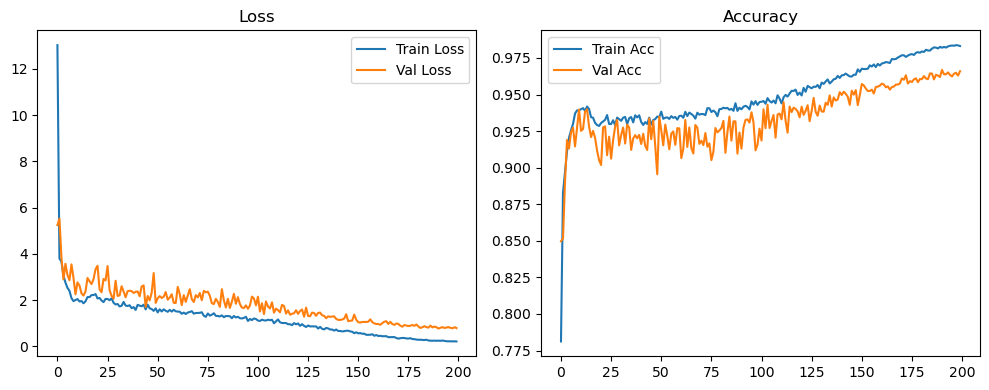

Original Model Final Test Loss: 0.7502 Accuracy: 0.9644


🚀 Running: batch256_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.8019 | Val Acc: 0.8524 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.8019 | Val Acc: 0.8524 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.8019 | Val Acc: 0.8524 | Epoch Time: 0.09 | :   0%|▌                                                                                                                  | 1/200 [00:05<17:15,  5.20s/it]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9787 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:10<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9787 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:14<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9787 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:14<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9787 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:14<00:00,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9787 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:14<00:00,  4.57s/it]

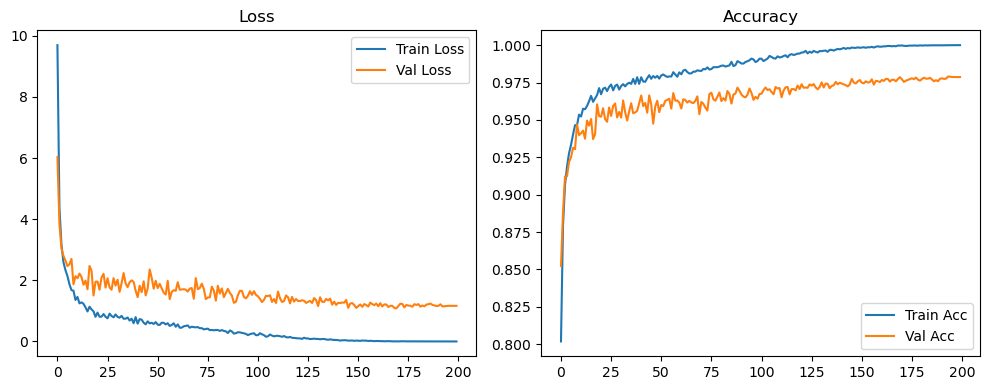

Original Model Final Test Loss: 0.9916 Accuracy: 0.9811


🚀 Running: batch256_lr_max_0.0002_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.7838 | Val Acc: 0.8442 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.7838 | Val Acc: 0.8442 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.7838 | Val Acc: 0.8442 | Epoch Time: 0.09 | :   0%|▌                                                                                                                  | 1/200 [00:05<17:58,  5.42s/it]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9768 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:10<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9768 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:15<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9768 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:15<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9768 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:15<00:00,  4.57s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9768 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:15<00:00,  4.58s/it]

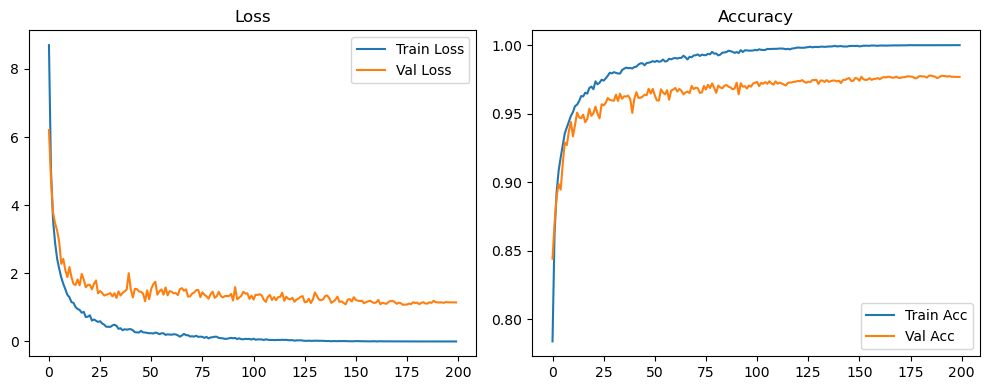

Original Model Final Test Loss: 0.9684 Accuracy: 0.9782


🚀 Running: batch256_lr_max_0.0001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.7572 | Val Acc: 0.8320 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.7572 | Val Acc: 0.8320 | Epoch Time: 0.09 | :   0%|                                                                                                                           | 0/200 [00:05<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.7572 | Val Acc: 0.8320 | Epoch Time: 0.09 | :   0%|▌                                                                                                                  | 1/200 [00:05<17:25,  5.25s/it]

...

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9748 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:09<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9747 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:14<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9747 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [15:14<00:04,  4.57s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9747 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:14<00:00,  4.55s/it]

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9747 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [15:14<00:00,  4.57s/it]

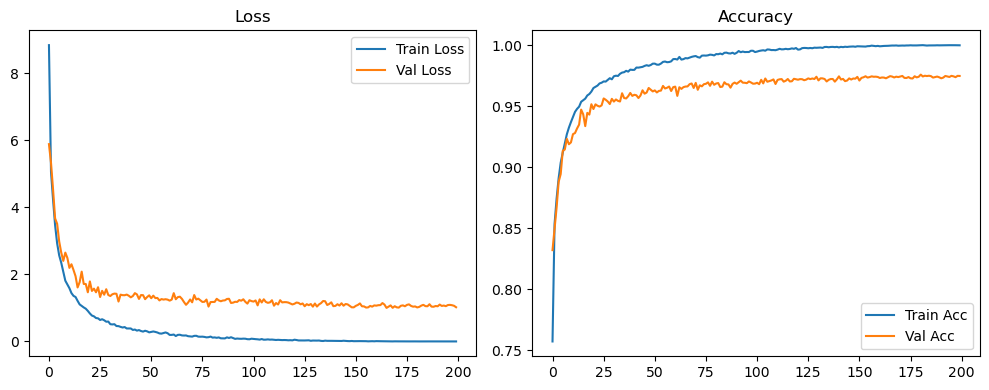

Original Model Final Test Loss: 0.8619 Accuracy: 0.9771


🚀 Running: batch512_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.7380 | Val Acc: 0.8551 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.7380 | Val Acc: 0.8551 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.7380 | Val Acc: 0.8551 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<16:07,  4.86s/it]

...

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9781 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:29<00:04,  4.06s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9783 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:33<00:04,  4.06s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9783 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:33<00:04,  4.06s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9783 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:33<00:00,  4.07s/it]

| LR: 0.000001 | Train Acc: 0.9999 | Val Acc: 0.9783 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:33<00:00,  4.07s/it]

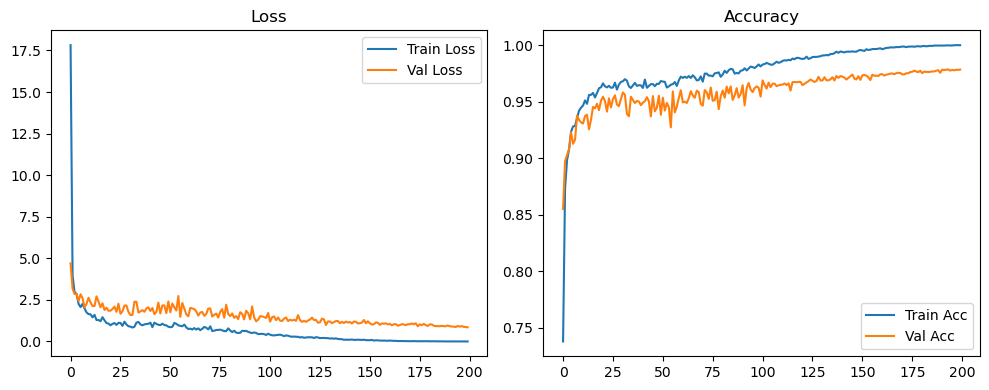

Original Model Final Test Loss: 0.8286 Accuracy: 0.9767


🚀 Running: batch512_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.7660 | Val Acc: 0.8516 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.7660 | Val Acc: 0.8516 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.7660 | Val Acc: 0.8516 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<16:06,  4.86s/it]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9785 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:31<00:04,  4.07s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9785 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:35<00:04,  4.07s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9785 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:35<00:04,  4.07s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9785 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:35<00:00,  4.07s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9785 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:35<00:00,  4.08s/it]

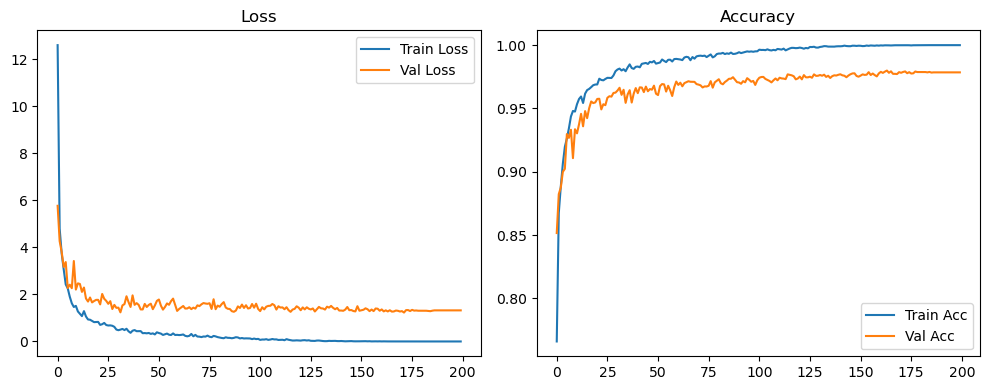

Original Model Final Test Loss: 1.2244 Accuracy: 0.9792


🚀 Running: batch512_lr_max_0.0002_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.7570 | Val Acc: 0.8413 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.7570 | Val Acc: 0.8413 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.7570 | Val Acc: 0.8413 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<16:03,  4.84s/it]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9750 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:31<00:04,  4.08s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9759 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:35<00:04,  4.08s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9759 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:35<00:04,  4.08s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9759 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:35<00:00,  4.07s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9759 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:35<00:00,  4.08s/it]

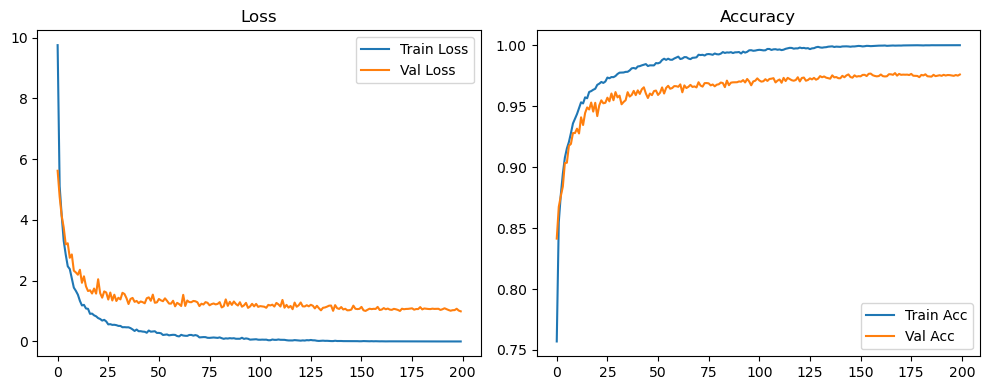

Original Model Final Test Loss: 0.8775 Accuracy: 0.9792


🚀 Running: batch512_lr_max_0.0001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.7091 | Val Acc: 0.8120 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.7091 | Val Acc: 0.8120 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.7091 | Val Acc: 0.8120 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<16:07,  4.86s/it]

...

| LR: 0.000001 | Train Acc: 0.9993 | Val Acc: 0.9705 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:31<00:04,  4.07s/it]

| LR: 0.000001 | Train Acc: 0.9991 | Val Acc: 0.9707 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:35<00:04,  4.07s/it]

| LR: 0.000001 | Train Acc: 0.9991 | Val Acc: 0.9707 | Epoch Time: 0.07 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [13:35<00:04,  4.07s/it]

| LR: 0.000001 | Train Acc: 0.9991 | Val Acc: 0.9707 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:35<00:00,  4.09s/it]

| LR: 0.000001 | Train Acc: 0.9991 | Val Acc: 0.9707 | Epoch Time: 0.07 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [13:35<00:00,  4.08s/it]

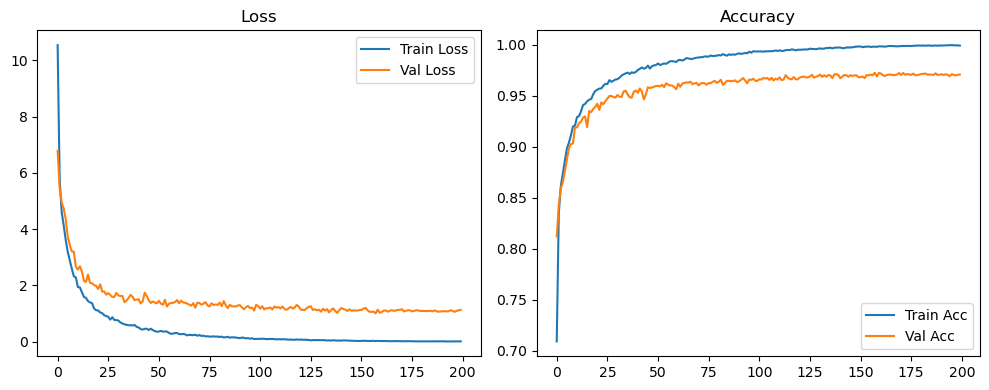

Original Model Final Test Loss: 0.9912 Accuracy: 0.9739


🚀 Running: batch1024_lr_max_0.001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5887 | Val Acc: 0.8157 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5887 | Val Acc: 0.8157 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.001000 | Train Acc: 0.5887 | Val Acc: 0.8157 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<15:52,  4.79s/it]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9788 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:50<00:03,  3.86s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9788 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:54<00:03,  3.86s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9788 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:54<00:03,  3.86s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9788 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:54<00:00,  3.86s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9788 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:54<00:00,  3.87s/it]

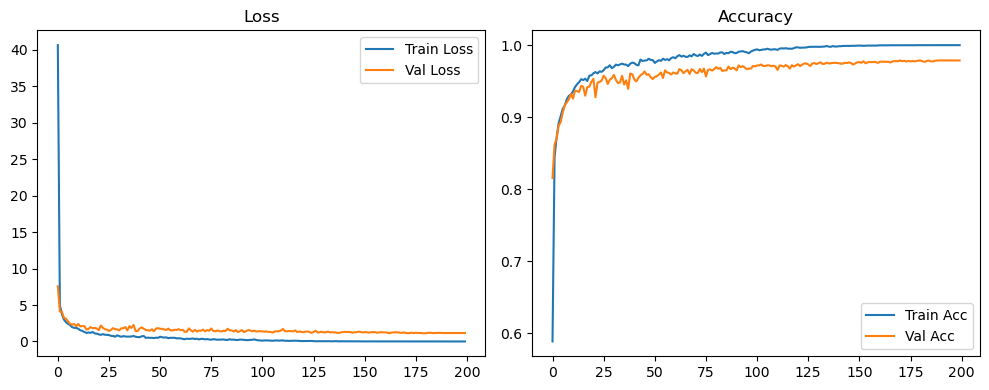

Original Model Final Test Loss: 1.0791 Accuracy: 0.9797


🚀 Running: batch1024_lr_max_0.0005_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6906 | Val Acc: 0.8259 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6906 | Val Acc: 0.8259 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000500 | Train Acc: 0.6906 | Val Acc: 0.8259 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<15:21,  4.63s/it]

...

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9763 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:53<00:03,  3.91s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9763 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:57<00:03,  3.91s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9763 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:57<00:03,  3.91s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9763 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:57<00:00,  3.91s/it]

| LR: 0.000001 | Train Acc: 1.0000 | Val Acc: 0.9763 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:57<00:00,  3.89s/it]

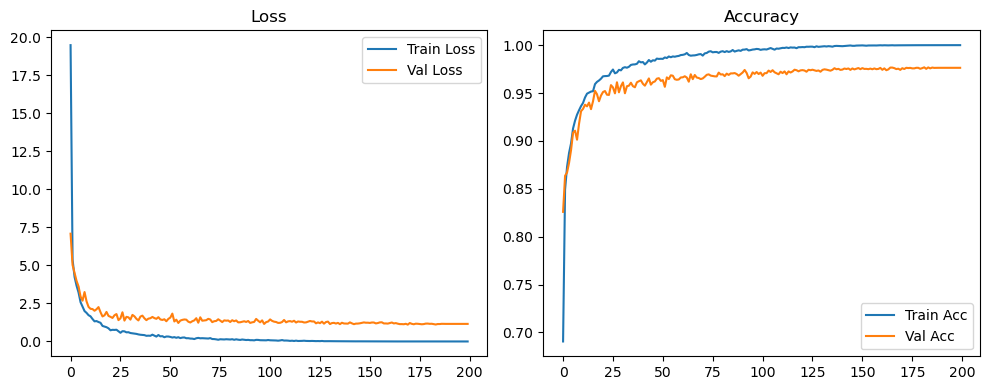

Original Model Final Test Loss: 0.9782 Accuracy: 0.9787


🚀 Running: batch1024_lr_max_0.0002_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6979 | Val Acc: 0.8263 | Epoch Time: 0.07 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6979 | Val Acc: 0.8263 | Epoch Time: 0.07 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000200 | Train Acc: 0.6979 | Val Acc: 0.8263 | Epoch Time: 0.07 | :   0%|▌                                                                                                                  | 1/200 [00:04<14:53,  4.49s/it]

...

| LR: 0.000001 | Train Acc: 0.9998 | Val Acc: 0.9720 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:55<00:03,  3.90s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9721 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:59<00:03,  3.90s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9721 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:59<00:03,  3.90s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9721 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:59<00:00,  3.91s/it]

| LR: 0.000001 | Train Acc: 0.9997 | Val Acc: 0.9721 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:59<00:00,  3.90s/it]

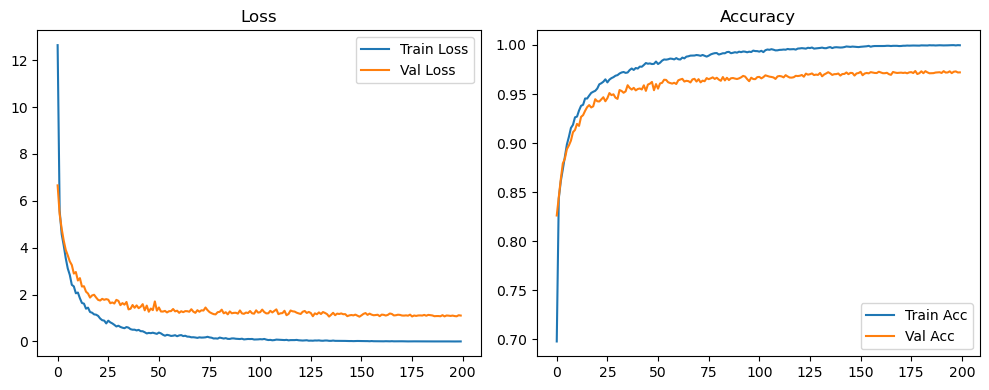

Original Model Final Test Loss: 0.9210 Accuracy: 0.9740


🚀 Running: batch1024_lr_max_0.0001_min_1e-06_dp0.0


Training:   0%|                                                                                                                                                                                             | 0/200 [00:00<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6308 | Val Acc: 0.7914 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6308 | Val Acc: 0.7914 | Epoch Time: 0.08 | :   0%|                                                                                                                           | 0/200 [00:04<?, ?it/s]

| LR: 0.000100 | Train Acc: 0.6308 | Val Acc: 0.7914 | Epoch Time: 0.08 | :   0%|▌                                                                                                                  | 1/200 [00:04<15:22,  4.63s/it]

...

| LR: 0.000001 | Train Acc: 0.9969 | Val Acc: 0.9677 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:55<00:03,  3.89s/it]

| LR: 0.000001 | Train Acc: 0.9975 | Val Acc: 0.9667 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:58<00:03,  3.89s/it]

| LR: 0.000001 | Train Acc: 0.9975 | Val Acc: 0.9667 | Epoch Time: 0.06 | : 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 199/200 [12:58<00:03,  3.89s/it]

| LR: 0.000001 | Train Acc: 0.9975 | Val Acc: 0.9667 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:59<00:00,  3.88s/it]

| LR: 0.000001 | Train Acc: 0.9975 | Val Acc: 0.9667 | Epoch Time: 0.06 | : 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:59<00:00,  3.90s/it]

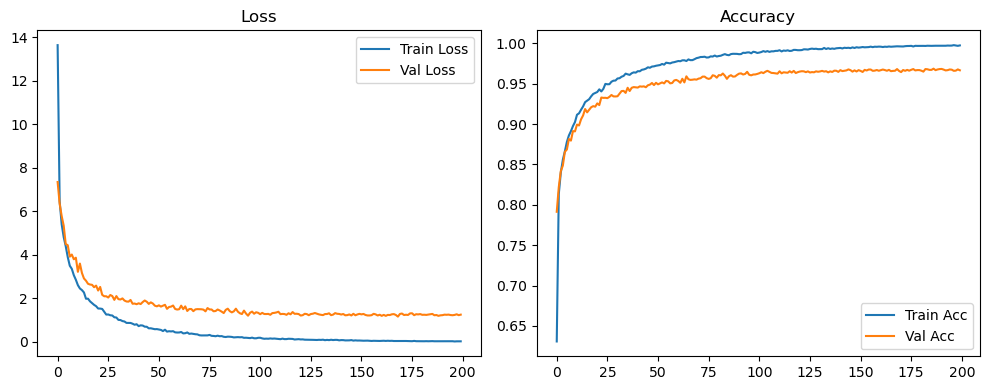

Original Model Final Test Loss: 1.0768 Accuracy: 0.9706




In [16]:
best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path  = Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)

In [17]:
best_evaluation(best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path)

Best model loaded.


Evaluation:   0%|                                                                                                                                                                                             | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|████████████████████████████████████████████████████████████▎                                                                                                                        | 1/3 [00:00<00:01,  1.57it/s]

Evaluation:  67%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                            | 2/3 [00:01<00:00,  1.59it/s]

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.13it/s]

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  1.95it/s]

Best Original Model Final Test Loss: 0.9916 Acc: 0.9811 


